# Análisis Exploratorio de datos (EDA) - Brazilian E-Commerce Olist Dataset

---

## Unidad 1: Fundamentos de diseño y modelado de datos

**Asignatura:** Diseño y Optimización de Bases de Datos - Grupo 2  
**Universidad de La Sabana**

---

## Objetivos de aprendizaje

1. **Explorar** la estructura y características del  Brazilian E-Commerce Olist Dataset
2. **Identificar** las relaciones entre entidades (customers, geolocation, order ítems, order payments, reviews, orders, products, sellers y category name)
3. **Analizar** la calidad de los datos: valores nulos, duplicados y anomalías
5. **Aplicar** principios de análisis exploratorio como fundamento para decisiones de diseño de bases de datos

## Contexto del dataset

Este conjunto de datos fue cedido por Olist, la tienda online más grande de los marketplaces brasileños.
Olist actúa como un intermediario que conecta a pequeñas y medianas empresas de todo Brasil con los principales canales de venta, simplificando el proceso mediante un único contrato.

###Funcionamiento:

1. Los comerciantes publican sus productos en la Olist Store.

2. Los clientes realizan sus compras en línea.

3. Olist notifica al vendedor para que procese y envíe el pedido a través de sus socios logísticos.

###Experiencia del cliente:
Una vez recibido el producto (o alcanzada la fecha estimada de entrega), el comprador recibe una encuesta de satisfacción por correo electrónico, donde puede:

1. Calificar su experiencia de compra.

2. Escribir comentarios sobre el producto y el servicio.

###Valor del dataset:
Este recurso permite analizar el ecosistema de e-commerce brasileño, incluyendo:

1. Procesos de venta y logística.

2. Métodos de pago y tiempos de entrega.

3. Opiniones y satisfacción de los clientes.

Más información sobre Olist en su página oficial: www.olist.com

**Alcance del análisis:** Este notebook se enfoca en las entidades principales del modelo relacional (customers, geolocation, order ítems, order payments, reviews, orders, products, sellers y category name) y sus relaciones jerárquicas. Por ende, este análisis se centra en las estructuras fundamentales necesarias para comprender normalización, desnormalización y diseño de bases de datos relacionales y NoSQL.


### Estructura del Dataset:
- **customers (canciones):** Información sobre cada cliente y su ubicación.
- **orders:** Conjunto de datos principal de cada orden.
- **sellers (álbumes):** Información sobre vendedores que han gestionado los pedidos realizados.
- **product_category_name:** Traducción del nombre de la categoría.  
- **products:** Información sobre los productos vendidos por Olist.
- **order_items:**  Información sobre los artículos comprados en cada pedido.
- **order_payments:** Información sobre las opciones de pago de los pedidos.
- **order_reviews:** Información sobre las opiniones de los clientes.
- **geolocation:** Información sobre los códigos postales brasileños y sus coordenadas de latitud y longitud



## 1️. Configuración del entorno

### Instalación de librerías necesarias

Se instalarán las bibliotecas requeridas para análisis de datos y visualización.

In [47]:
# Instalación de librerías adicionales si es necesario
!pip install pandas numpy matplotlib seaborn plotly --quiet

print("Librerías instaladas correctamente")

Librerías instaladas correctamente


In [48]:
### Importación de bibliotecas

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

# Configuración de visualización
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Configuración de tamaños de figura por defecto
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Bibliotecas importadas correctamente")
print(f"Versión de pandas: {pd.__version__}")
print(f"Versión de numpy: {np.__version__}")

Bibliotecas importadas correctamente
Versión de pandas: 2.2.2
Versión de numpy: 2.0.2


---

## 2️. Carga del Dataset

### Carga del Brazilian E-Commerce Olist Dataset

Se cargará el dataset desde una fuente pública. Los archivos contienen información consolidada de customers, geolocation, order ítems, order payments, reviews, orders, products, sellers y category name.

In [50]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


Enumerar los archivos CSV de la carpeta de Drive especificada directorio MyDrive/MaestríaArqSw/DiseñoOptimizacionBD/Dataset_BrazilianE

In [51]:
import os

drive_path = '/content/drive/MyDrive/MaestríaArqSw/DiseñoOptimizacionBD/Dataset_BrazilianE'

# Check archivos
if os.path.exists(drive_path):
    print(f"Listado de archivos: {drive_path}")
    csv_files = [f for f in os.listdir(drive_path) if f.endswith('.csv')]
    if csv_files:
        print("Archivos CSV encontrados:")
        for f in csv_files:
            print(f"- {f}")
    else:
        print("No se encntraron archivos CSV en este directorio.")
else:
    print(f"Error: Directorio no encontrado {drive_path}")
    csv_files = []

Listado de archivos: /content/drive/MyDrive/MaestríaArqSw/DiseñoOptimizacionBD/Dataset_BrazilianE
Archivos CSV encontrados:
- product_category_name_translation.csv
- olist_orders_dataset.csv
- olist_geolocation_dataset.csv
- olist_order_reviews_dataset.csv
- olist_products_dataset.csv
- olist_sellers_dataset.csv
- olist_customers_dataset.csv
- olist_order_payments_dataset.csv
- olist_order_items_dataset.csv


## 3️. Exploración de la estructura

### 3.1 Información general del dataset

Se analizará la estructura del dataset: tipos de datos, columnas presentes y uso de memoria.

In [52]:
import pandas as pd

print("INFORMACIÓN GENERAL DEL DATASET")
print("=" * 80)

for csv_file_name in csv_files:
    file_path = os.path.join(drive_path, csv_file_name)
    print(f"\n--- Procesando archivo: {csv_file_name} ---")
    try:
        df = pd.read_csv(file_path)
        print(f"DataFrame '{csv_file_name}' carga exitosa.")

        print("\nInformacion sobre el DataFrame (Column, Non-Null counts, Dtype):\n")
        df.info()

        print(f"\nResumen: {df.shape[0]:,} registros distribuidos en {df.shape[1]} atributos\n")

        print("\nDescripción entidad:\n")
        display(df.describe(include='all'))

    except Exception as e:
        print(f"Error cargando o procesando {csv_file_name}: {e}")


INFORMACIÓN GENERAL DEL DATASET

--- Procesando archivo: product_category_name_translation.csv ---
DataFrame 'product_category_name_translation.csv' carga exitosa.

Informacion sobre el DataFrame (Column, Non-Null counts, Dtype):

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB

Resumen: 71 registros distribuidos en 2 atributos


Descripción entidad:



,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1



--- Procesando archivo: olist_orders_dataset.csv ---
DataFrame 'olist_orders_dataset.csv' carga exitosa.

Informacion sobre el DataFrame (Column, Non-Null counts, Dtype):

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB

Resumen: 99,441 registros distribuidos en 8 atributos


Descripción entidad:



,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522



--- Procesando archivo: olist_geolocation_dataset.csv ---
DataFrame 'olist_geolocation_dataset.csv' carga exitosa.

Informacion sobre el DataFrame (Column, Non-Null counts, Dtype):

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB

Resumen: 1,000,163 registros distribuidos en 5 atributos


Descripción entidad:



...

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,274fa6071e5e17fe303b9748641082c8,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN



--- Procesando archivo: olist_order_payments_dataset.csv ---
DataFrame 'olist_order_payments_dataset.csv' carga exitosa.

Informacion sobre el DataFrame (Column, Non-Null counts, Dtype):

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB

Resumen: 103,886 registros distribuidos en 5 atributos


Descripción entidad:



,order_id,payment_sequential,payment_type,payment_installments,payment_value
count,103886,103886.000000,103886,103886.000000,103886.000000
unique,99440,NaN,5,NaN,NaN
top,fa65dad1b0e818e3ccc5cb0e39231352,NaN,credit_card,NaN,NaN
freq,29,NaN,76795,NaN,NaN
mean,NaN,1.092679,NaN,2.853349,154.100380
std,NaN,0.706584,NaN,2.687051,217.494064
min,NaN,1.000000,NaN,0.000000,0.000000
25%,NaN,1.000000,NaN,1.000000,56.790000
50%,NaN,1.000000,NaN,1.000000,100.000000
75%,NaN,1.000000,NaN,4.000000,171.837500



--- Procesando archivo: olist_order_items_dataset.csv ---
DataFrame 'olist_order_items_dataset.csv' carga exitosa.

Informacion sobre el DataFrame (Column, Non-Null counts, Dtype):

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB

Resumen: 112,650 registros distribuidos en 7 atributos


Descripción entidad:



,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
count,112650,112650.000000,112650,112650,112650,112650.000000,112650.000000
unique,98666,NaN,32951,3095,93318,NaN,NaN
top,8272b63d03f5f79c56e9e4120aec44ef,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,2017-07-21 18:25:23,NaN,NaN
freq,21,NaN,527,2033,21,NaN,NaN
mean,NaN,1.197834,NaN,NaN,NaN,120.653739,19.990320
std,NaN,0.705124,NaN,NaN,NaN,183.633928,15.806405
min,NaN,1.000000,NaN,NaN,NaN,0.850000,0.000000
25%,NaN,1.000000,NaN,NaN,NaN,39.900000,13.080000
50%,NaN,1.000000,NaN,NaN,NaN,74.990000,16.260000
75%,NaN,1.000000,NaN,NaN,NaN,134.900000,21.150000


In [53]:
import pandas as pd
import os

print("\nANÁLISIS DE CARDINALIDAD ENTRE ENTIDADES")
print("=" * 80)

dfs = {}

print("\n--- Listado de columnas de cada DataFrame ---")
for csv_file_name in csv_files:
    df_name = os.path.splitext(csv_file_name)[0]
    file_path = os.path.join(drive_path, csv_file_name)
    try:
        df = pd.read_csv(file_path)
        dfs[df_name] = df
        print(f"\nColumnas en '{df_name}':")
        for col in df.columns:
            print(f"- {col}")
    except Exception as e:
        print(f"Error cargando {csv_file_name}: {e}")


from collections import defaultdict

column_presence = defaultdict(list)

for df_name, df in dfs.items():
    for col in df.columns:
        column_presence[col].append(df_name)

print("\n--- Se identificaron posibles relaciones basadas en columnas comunes. ---\n")
for col, df_list in column_presence.items():
    if len(df_list) > 1:
        print(f"Relación potencial a través de la columna '{col}' entre: {', '.join(df_list)}")


ANÁLISIS DE CARDINALIDAD ENTRE ENTIDADES

--- Listado de columnas de cada DataFrame ---

Columnas en 'product_category_name_translation':
- product_category_name
- product_category_name_english

Columnas en 'olist_orders_dataset':
- order_id
- customer_id
- order_status
- order_purchase_timestamp
- order_approved_at
- order_delivered_carrier_date
- order_delivered_customer_date
- order_estimated_delivery_date

Columnas en 'olist_geolocation_dataset':
- geolocation_zip_code_prefix
- geolocation_lat
- geolocation_lng
- geolocation_city
- geolocation_state

Columnas en 'olist_order_reviews_dataset':
- review_id
- order_id
- review_score
- review_comment_title
- review_comment_message
- review_creation_date
- review_answer_timestamp

Columnas en 'olist_products_dataset':
- product_id
- product_category_name
- product_name_lenght
- product_description_lenght
- product_photos_qty
- product_weight_g
- product_length_cm
- product_height_cm
- product_width_cm

Columnas en 'olist_sellers_datase

----

## 4️. Análisis de relaciones entre entidades

### 4.1 Identificación de entidades

En el contexto del Brazilian E-Commerce Olist Dataset, se han identificado las siguientes entidades principales y sus posibles relaciones basadas en columnas comunes:

-   **product_category_name_translation** y **olist_products_dataset** están relacionados a través de la columna `product_category_name`.
-   **olist_orders_dataset**, **olist_order_reviews_dataset**, **olist_order_payments_dataset**, y **olist_order_items_dataset** están relacionados a través de la columna `order_id`.
-   **olist_orders_dataset** y **olist_customers_dataset** están relacionados a través de la columna `customer_id`.
-   **olist_products_dataset** y **olist_order_items_dataset** están relacionados a través de la columna `product_id`.
-   **olist_sellers_dataset** y **olist_order_items_dataset** están relacionados a través de la columna `seller_id`.

### 4.2 Descripción funcional de las relaciones

Basándonos en las columnas comunes, podemos inferir las siguientes relaciones funcionales entre las entidades:

-   **`product_category_name`**: Permite relacionar las categorías de productos de la tabla `olist_products_dataset` con sus traducciones al inglés en `product_category_name_translation`. Esto facilita el análisis y la comprensión de las categorías de productos en un idioma común.

-   **`order_id`**: Es la clave principal que vincula la información de los pedidos en `olist_orders_dataset` con detalles adicionales en otras tablas:
    -   Con `olist_order_reviews_dataset`: Una orden puede tener una o varias revisiones/observaciones asociadas.
    -   Con `olist_order_payments_dataset`: Una orden puede tener uno o varios pagos registrados, lo que permite detallar los métodos y valores de pago.
    -   Con `olist_order_items_dataset`: Una orden contiene uno o varios ítems de productos que fueron comprados, detallando qué productos específicos se incluyeron en cada pedido.

-   **`customer_id`**: Vincula la información de los clientes en `olist_customers_dataset` con los pedidos que realizaron en `olist_orders_dataset`. Un cliente puede haber realizado múltiples pedidos.

-   **`product_id`**: Relaciona los productos en `olist_products_dataset` con los ítems individuales de pedidos en `olist_order_items_dataset`. Un producto puede aparecer en múltiples ítems de pedido a través de diferentes órdenes.

-   **`seller_id`**: Conecta la información de los vendedores en `olist_sellers_dataset` con los ítems de pedidos en `olist_order_items_dataset`. Un vendedor puede haber vendido múltiples ítems en diferentes pedidos.

In [54]:
print("ANÁLISIS CALDIAD DE LOS DATOS")
print("=" * 80)

# List of file names to process (original names from the prompt)
df_names_files = [
    'product_category_name_translation.csv',
    'olist_orders_dataset.csv',
    'olist_geolocation_dataset.csv',
    'olist_order_reviews_dataset',
    'olist_products_dataset',
    'olist_sellers_dataset',
    'olist_customers_dataset',
    'olist_order_payments_dataset',
    'olist_order_items_dataset'
]

# Iterate through the specified list of DataFrame names
for original_file_name in df_names_files:
    # Get the key for the dfs dictionary by stripping the .csv extension
    df_key = os.path.splitext(original_file_name)[0]

    if df_key in dfs: # Check if the DataFrame is loaded in dfs
        df = dfs[df_key]
        print(f"\n--- Analyzing DataFrame: '{original_file_name}' ---")

        # Missing Values Analysis
        missing_values = df.isnull().sum()
        missing_percentage = ((df.isnull().sum() / len(df)) * 100).round(2)
        missing_info = pd.DataFrame({
            'Cuenta faltante': missing_values,
            'Porcentaje faltante': missing_percentage
        })
        missing_info = missing_info[missing_info['Cuenta faltante'] > 0]

        if not missing_info.empty:
            print("\n**Se encontraron valores faltantes** \n Valores perdidos:")
            display(missing_info.sort_values(by='Porcentaje faltante', ascending=False))
        else:
            print("\n**No se encontraron valores faltantes**.")

        # Data Types
        print("\nTipos de Datos:") # Fixed: changed \T to \n
        print(df.dtypes)

        # Unique Values Count
        print("\nValores únicos por columna:")
        for col in df.columns:
            num_unique = df[col].nunique()
            print(f"     - {col}: {num_unique} Valores unicos")
    else:
        print(f"Advertencia: DataFrame '{original_file_name}' no encontrado en 'dfs'. Saltando análisis.")

ANÁLISIS CALDIAD DE LOS DATOS

--- Analyzing DataFrame: 'product_category_name_translation.csv' ---

**No se encontraron valores faltantes**.

Tipos de Datos:
product_category_name            object
product_category_name_english    object
dtype: object

Valores únicos por columna:
     - product_category_name: 71 Valores unicos
     - product_category_name_english: 71 Valores unicos

--- Analyzing DataFrame: 'olist_orders_dataset.csv' ---

**Se encontraron valores faltantes** 
 Valores perdidos:


,Cuenta faltante,Porcentaje faltante
order_delivered_customer_date,2965,2.98
order_delivered_carrier_date,1783,1.79
order_approved_at,160,0.16



Tipos de Datos:
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

Valores únicos por columna:
     - order_id: 99441 Valores unicos
     - customer_id: 99441 Valores unicos
     - order_status: 8 Valores unicos
     - order_purchase_timestamp: 98875 Valores unicos
     - order_approved_at: 90733 Valores unicos
     - order_delivered_carrier_date: 81018 Valores unicos
     - order_delivered_customer_date: 95664 Valores unicos
     - order_estimated_delivery_date: 459 Valores unicos

--- Analyzing DataFrame: 'olist_geolocation_dataset.csv' ---

**No se encontraron valores faltantes**.

Tipos de Datos:
geolocation_zip_code_prefix      int64
geolocation_lat                float64
geolocation_lng              

,Cuenta faltante,Porcentaje faltante
review_comment_title,87656,88.34
review_comment_message,58247,58.70



Tipos de Datos:
review_id                  object
order_id                   object
review_score                int64
review_comment_title       object
review_comment_message     object
review_creation_date       object
review_answer_timestamp    object
dtype: object

Valores únicos por columna:
     - review_id: 98410 Valores unicos
     - order_id: 98673 Valores unicos
     - review_score: 5 Valores unicos
     - review_comment_title: 4527 Valores unicos
     - review_comment_message: 36159 Valores unicos
     - review_creation_date: 636 Valores unicos
     - review_answer_timestamp: 98248 Valores unicos

--- Analyzing DataFrame: 'olist_products_dataset' ---

**Se encontraron valores faltantes** 
 Valores perdidos:


,Cuenta faltante,Porcentaje faltante
product_category_name,610,1.85
product_name_lenght,610,1.85
product_description_lenght,610,1.85
product_photos_qty,610,1.85
product_weight_g,2,0.01
product_length_cm,2,0.01
product_height_cm,2,0.01
product_width_cm,2,0.01



Tipos de Datos:
product_id                     object
product_category_name          object
product_name_lenght           float64
product_description_lenght    float64
product_photos_qty            float64
product_weight_g              float64
product_length_cm             float64
product_height_cm             float64
product_width_cm              float64
dtype: object

Valores únicos por columna:
     - product_id: 32951 Valores unicos
     - product_category_name: 73 Valores unicos
     - product_name_lenght: 66 Valores unicos
     - product_description_lenght: 2960 Valores unicos
     - product_photos_qty: 19 Valores unicos
     - product_weight_g: 2204 Valores unicos
     - product_length_cm: 99 Valores unicos
     - product_height_cm: 102 Valores unicos
     - product_width_cm: 95 Valores unicos

--- Analyzing DataFrame: 'olist_sellers_dataset' ---

**No se encontraron valores faltantes**.

Tipos de Datos:
seller_id                 object
seller_zip_code_prefix     int64
seller_c

## 5. Visualización de Distribuciones Temporales y Geográficas

Analicemos cómo se distribuyen los pedidos a lo largo del tiempo y la concentración geográfica de clientes y vendedores.

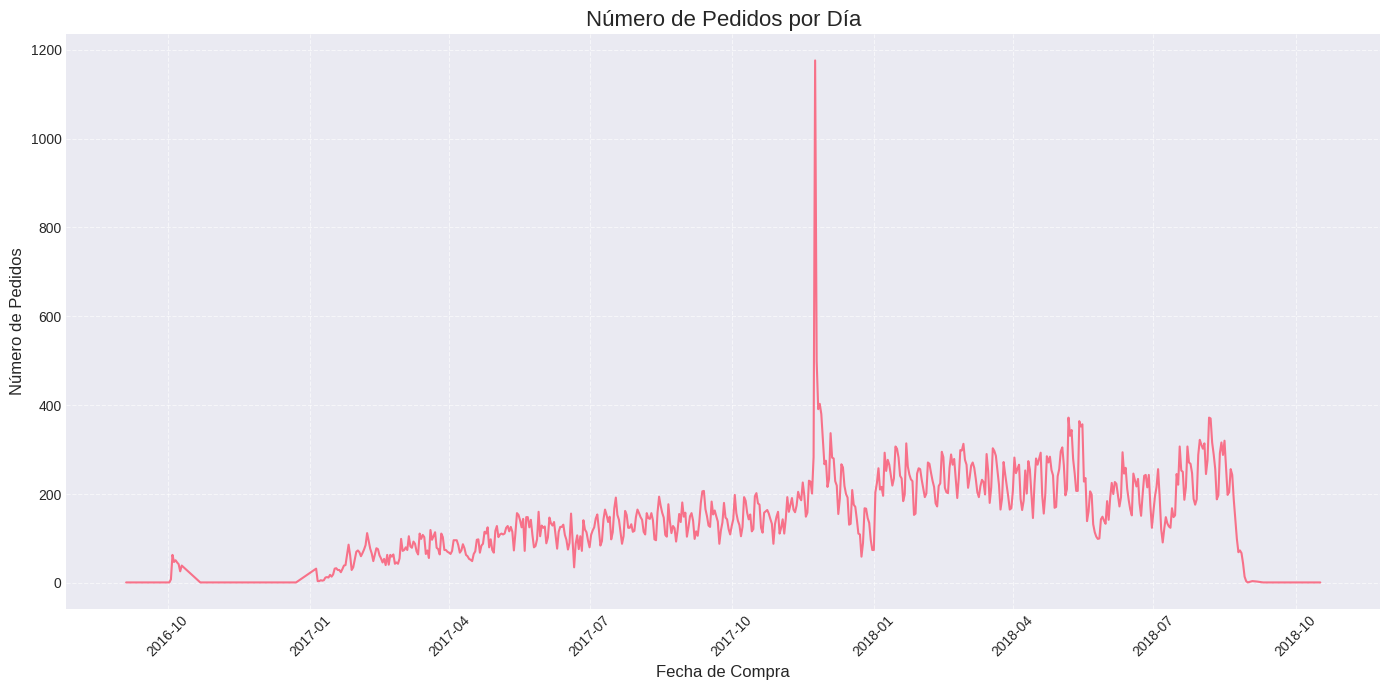

In [55]:
# Convertir las columnas de fecha a tipo datetime en el DataFrame de órdenes
orders_df = dfs['olist_orders_dataset'].copy()
date_columns = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in date_columns:
    orders_df[col] = pd.to_datetime(orders_df[col])

# Agrupar por fecha de compra y contar el número de pedidos
daily_orders = orders_df.groupby(orders_df['order_purchase_timestamp'].dt.date).size().reset_index(name='order_count')
daily_orders['order_purchase_timestamp'] = pd.to_datetime(daily_orders['order_purchase_timestamp'])

# Plotear la distribución temporal de pedidos
plt.figure(figsize=(14, 7))
sns.lineplot(x='order_purchase_timestamp', y='order_count', data=daily_orders)
plt.title('Número de Pedidos por Día', fontsize=16)
plt.xlabel('Fecha de Compra', fontsize=12)
plt.ylabel('Número de Pedidos', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### 5.1 Distribución geográfica de clientes por estado

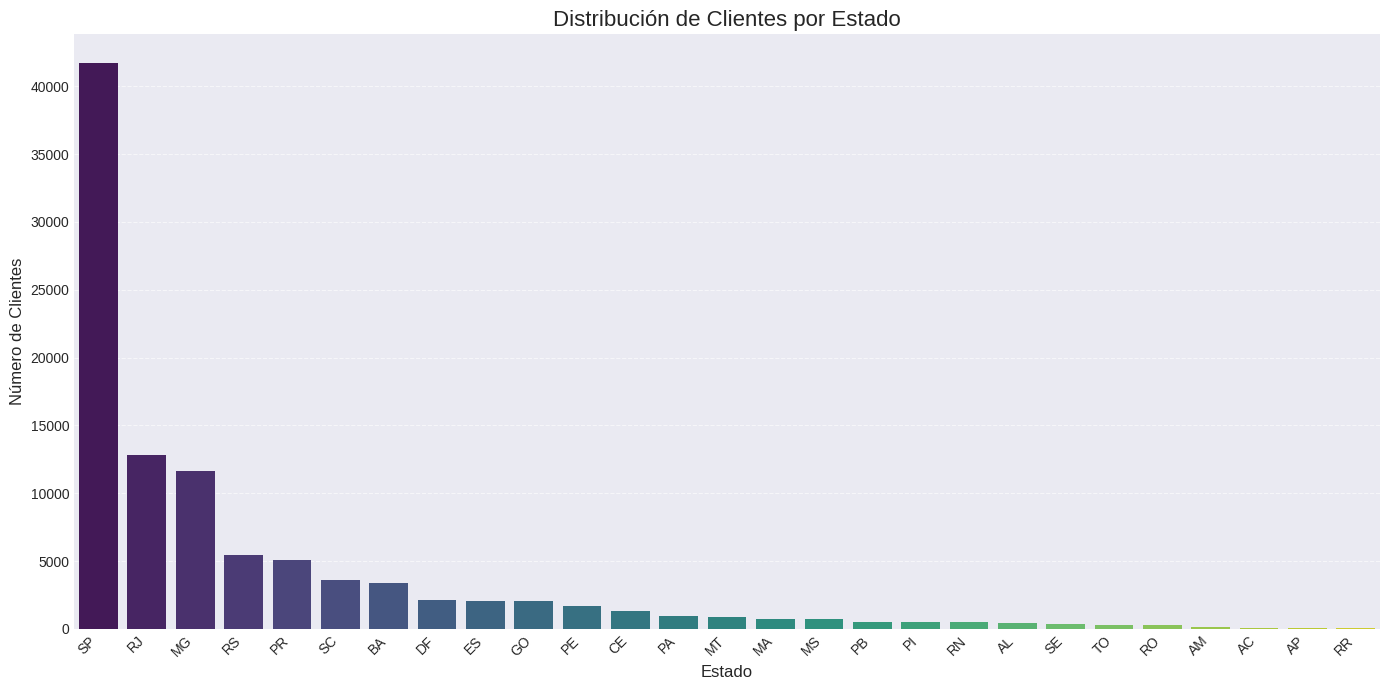

In [56]:
# Distribución geográfica de clientes por estado
customers_df = dfs['olist_customers_dataset'].copy()
customer_state_counts = customers_df['customer_state'].value_counts().reset_index()
customer_state_counts.columns = ['state', 'customer_count']

plt.figure(figsize=(14, 7))
sns.barplot(x='state', y='customer_count', data=customer_state_counts, palette='viridis')
plt.title('Distribución de Clientes por Estado', fontsize=16)
plt.xlabel('Estado', fontsize=12)
plt.ylabel('Número de Clientes', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### 5.2 Distribución geográfica de vendedores por estado

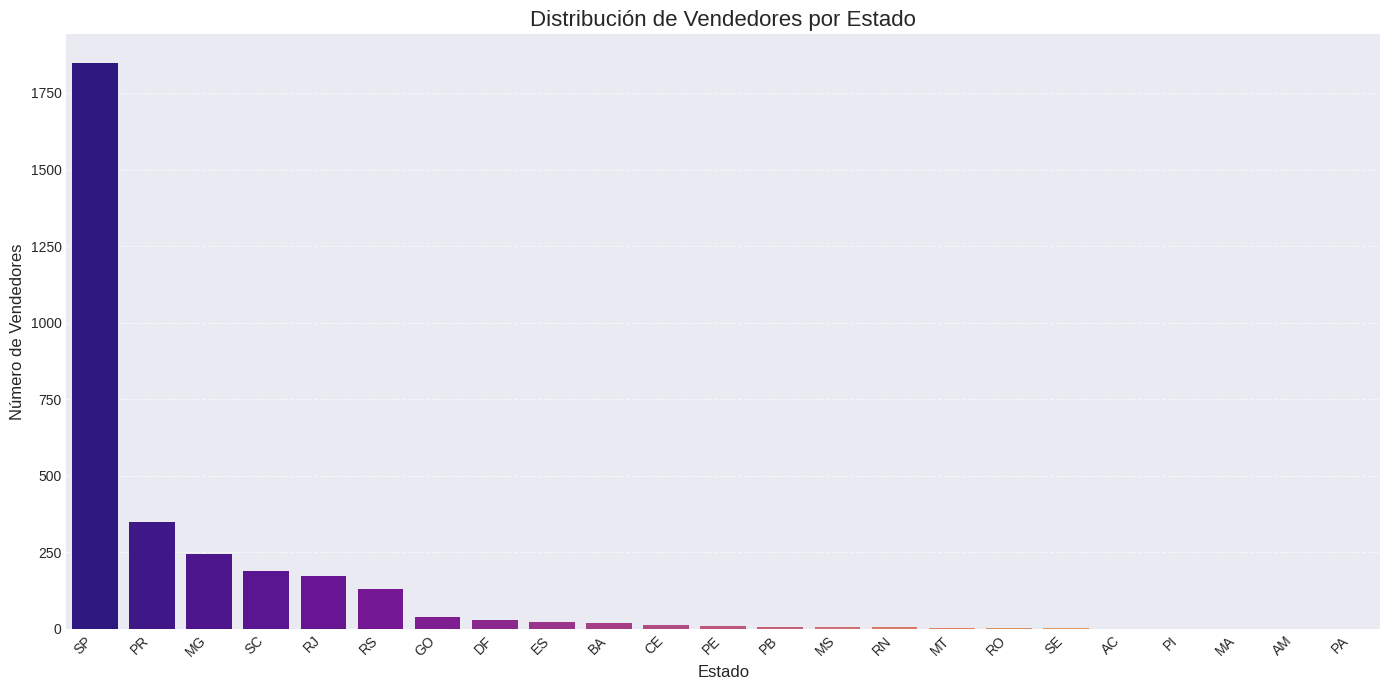

In [57]:
# Distribución geográfica de vendedores por estado
sellers_df = dfs['olist_sellers_dataset'].copy()
seller_state_counts = sellers_df['seller_state'].value_counts().reset_index()
seller_state_counts.columns = ['state', 'seller_count']

plt.figure(figsize=(14, 7))
sns.barplot(x='state', y='seller_count', data=seller_state_counts, palette='plasma')
plt.title('Distribución de Vendedores por Estado', fontsize=16)
plt.xlabel('Estado', fontsize=12)
plt.ylabel('Número de Vendedores', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Visualización de datos geográficos...


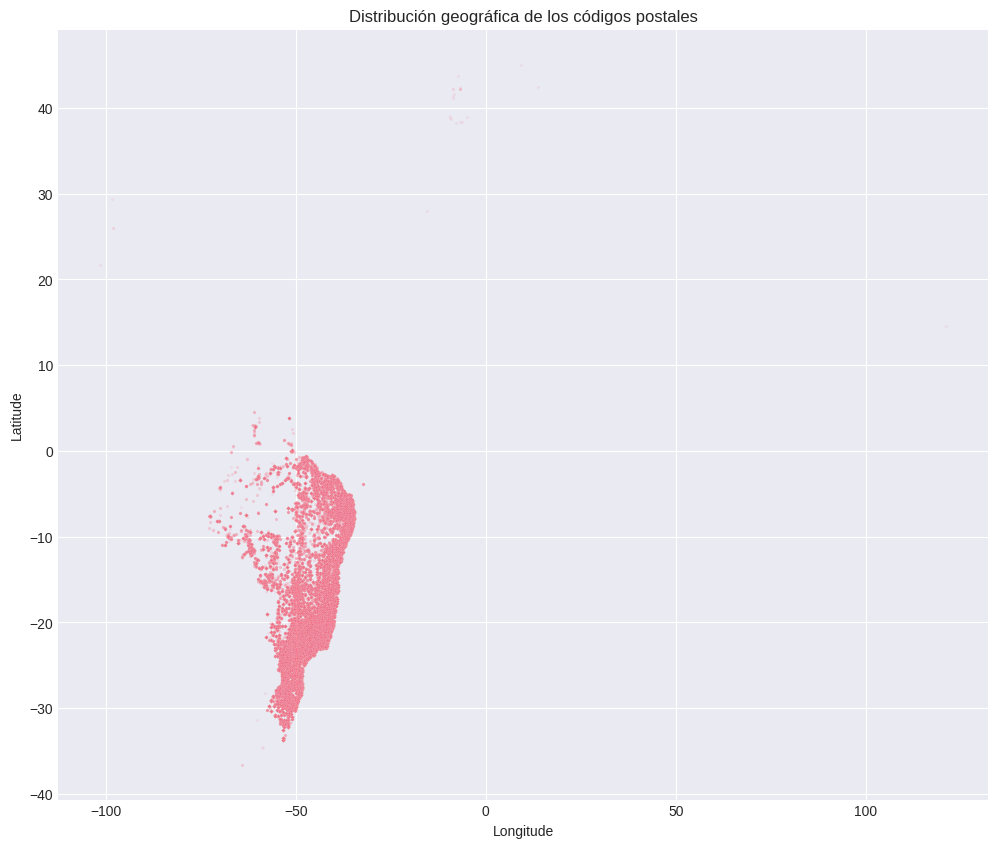

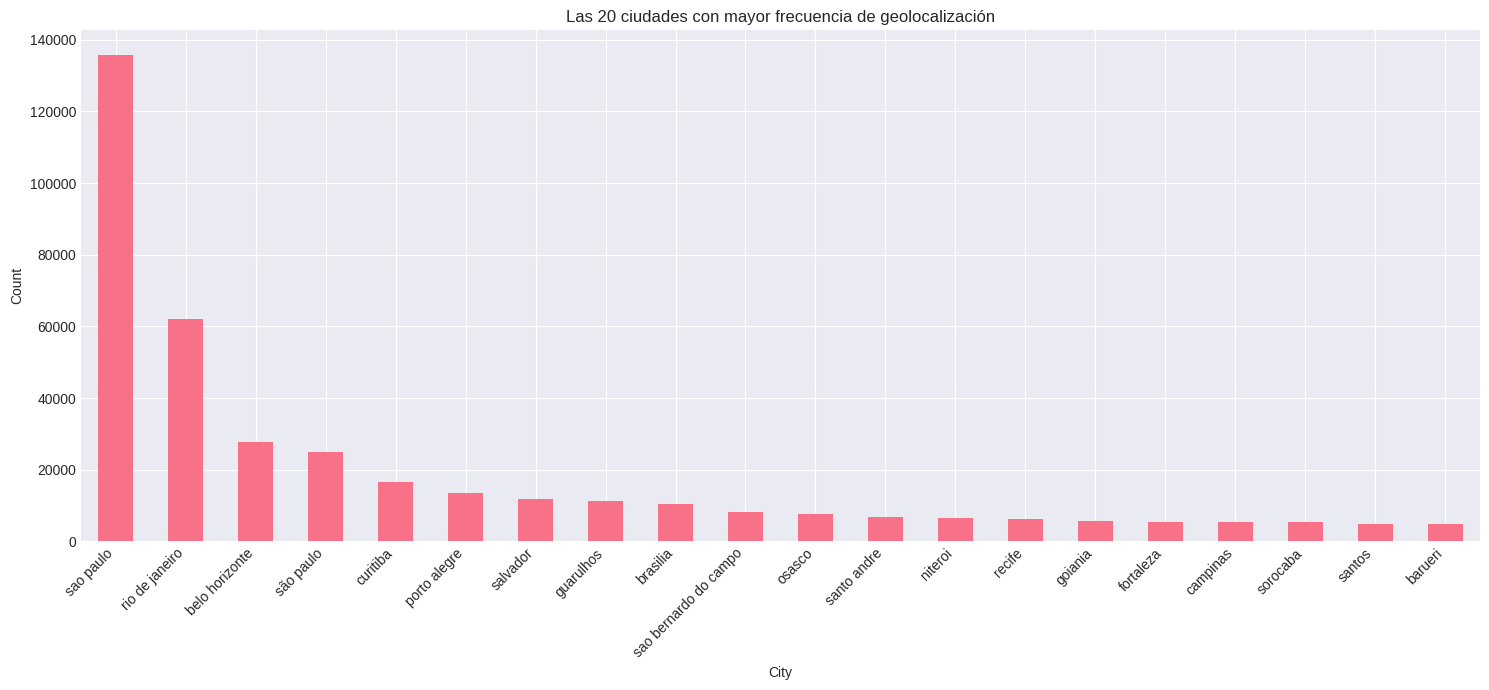

In [58]:
# 'olist_geolocation_dataset'
geolocation_df = dfs.get('olist_geolocation_dataset')

if geolocation_df is not None:
    print("Visualización de datos geográficos...")

    plt.figure(figsize=(12, 10))
    sns.scatterplot(x='geolocation_lng', y='geolocation_lat', data=geolocation_df, alpha=0.1, s=5)
    plt.title('Distribución geográfica de los códigos postales')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.grid(True)
    plt.show()

    # Top 20 most frequent cities
    plt.figure(figsize=(15, 7))
    geolocation_df['geolocation_city'].value_counts().head(20).plot(kind='bar')
    plt.title('Las 20 ciudades con mayor frecuencia de geolocalización')
    plt.xlabel('City')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

else:
    print("Error: 'olist_geolocation_dataset' DataFrame no encontrado.")


## 6️. Documentación de Hallazgos

A continuación, se resumen los hallazgos clave sobre la estructura, volumen y características de los datos del Brazilian E-Commerce Olist Dataset, basados en el análisis exploratorio realizado hasta el momento.

### 6.1 Estructura y Volumen de los Datos

El dataset se compone de nueve archivos CSV, cada uno representando una entidad principal con un volumen considerable de registros:

*   **`olist_geolocation_dataset`**: Contiene más de 1 millón de registros de geolocalización, lo que indica una alta granularidad espacial.
*   **`olist_orders_dataset`**: Con casi 100,000 registros, es el corazón del negocio, detallando cada pedido realizado.
*   **`olist_customers_dataset`**: También cercano a 100,000 registros, con información de los clientes.
*   **`olist_order_items_dataset`**: Más de 112,000 registros, reflejando que cada pedido puede contener múltiples ítems.
*   Las demás tablas (`product_category_name_translation`, `olist_order_reviews_dataset`, `olist_products_dataset`, `olist_sellers_dataset`, `olist_order_payments_dataset`) varían en volumen, proporcionando detalles específicos sobre categorías, reseñas, productos, vendedores y pagos, respectivamente.

Las columnas varían en tipo, predominando los `object` (cadenas, a menudo identificadores o descripciones), `int64` (códigos postales, puntuaciones) y `float64` (coordenadas geográficas, precios, valores de pago). La conversión a tipos de fecha (`datetime`) para las columnas de tiempo es crucial para el análisis temporal.

### 6.2 Relaciones entre Entidades

Las relaciones identificadas a través de columnas comunes son fundamentales para entender el ecosistema de Olist:

*   **`product_category_name`**: Conecta las categorías de productos con sus traducciones, esencial para la uniformidad lingüística.
*   **`order_id`**: Es el identificador central de los pedidos, enlazando `olist_orders_dataset` con `olist_order_reviews_dataset` (reseñas), `olist_order_payments_dataset` (pagos) y `olist_order_items_dataset` (productos del pedido). Una orden puede tener múltiples pagos, ítems y una o más revisiones.
*   **`customer_id`**: Vincula `olist_orders_dataset` con `olist_customers_dataset`, permitiendo analizar el historial de pedidos de cada cliente.
*   **`product_id`**: Relaciona `olist_products_dataset` con `olist_order_items_dataset`, mostrando qué productos se venden y en qué pedidos.
*   **`seller_id`**: Conecta `olist_sellers_dataset` con `olist_order_items_dataset`, permitiendo el análisis del rendimiento y la oferta de cada vendedor.

### 6.3 Calidad de los Datos

El análisis de calidad reveló lo siguiente:

*   **Valores Nulos**: Se identificaron valores faltantes significativos en columnas de fecha en `olist_orders_dataset` (ej. `order_delivered_customer_date`), y en campos de texto opcionales como `review_comment_title` y `review_comment_message` en `olist_order_reviews_dataset`. También hay nulos en descripciones de productos (`product_category_name`, `product_name_lenght`, etc.) y en algunas columnas de `olist_order_reviews_dataset` y `olist_products_dataset`.
*   **Valores Únicos**: La cardinalidad de los identificadores (`order_id`, `customer_id`, `product_id`, `seller_id`) es alta, lo que indica la unicidad esperada para estas claves. Otras columnas como `order_status` o `geolocation_state` muestran un número limitado de valores únicos, lo cual es coherente con su naturaleza categórica.

### 6.4 Distribuciones Temporales y Geográficas

Las visualizaciones mostraron patrones interesantes:

*   **Distribución Temporal de Pedidos**: El gráfico de líneas de pedidos por día reveló fluctuaciones diarias, pero se necesita un análisis más profundo para identificar tendencias estacionales o anuales claras. El mapa de calor de pedidos por día y mes permitirá identificar patrones de volumen de pedidos en momentos específicos del año.
*   **Distribución Geográfica de Clientes y Vendedores**: Los gráficos de barras mostraron una concentración significativa de clientes y vendedores en estados específicos de Brasil (ej. SP, RJ, MG), lo que subraya la importancia de ciertas regiones en el ecosistema de Olist. El mapa de calor del dataset de geolocalización proporciona una visión densa de las ubicaciones registradas, revelando los centros de actividad geográfica.